# KrediRadar — Seviye 1 (Tam Sürüm): EDA + İstatistiksel Testler + Preprocessing + Modelleme + MLflow

**Veri seti:** German Credit Data (Statlog, UCI) — 954 kayıt, kredi risk etiketiyle
**Metodoloji:** Veri önce train/test olarak ayrılır. EDA, istatistiksel testler, preprocessing,
feature engineering, feature selection ve model seçimi **sadece train üzerinde** yapılır.
Test verisi sadece final değerlendirme için, en sona kadar dokunulmadan bekletilir.

**Not — Bu şablondan atlanan/uyarlanan maddeler:**
- *Zaman Serisi Analizi (Elektrik Özel)*, Feature Engineering'deki *Lag/Rolling/Cyclic/Tarih özellikleri*
  ve *V×I, Temp², Load Factor, PF, Voltage Imbalance* maddeleri: bu veri setinde zaman boyutu
  ve elektrik mühendisliği bağlamı yok, tamamen atlandı.
- *Regression metrikleri*: problem sınıflandırma, regresyon metrikleri kullanılmadı.
- *One-Way ANOVA / Kruskal-Wallis*: hedef değişken ikili (2 sınıf), t-test/Mann-Whitney U yeterli.
- *SMOTE/ADASYN/Borderline/NearMiss*: veri küçük (954 satır) ve dengesizlik aşırı değil (%70/%30),
  sentetik oversampling yerine `class_weight='balanced'` kullanıldı.
- *LightGBM, CatBoost, SVM*: Logistic Regression + Random Forest + XGBoost üçü, bu veri boyutunda
  yeterli çeşitliliği sağlıyor.
- *TimeSeriesSplit*: zaman boyutu yok, StratifiedKFold kullanıldı.
- *Tam Optuna optimizasyonu*: roadmap'in İleri MLOps Seviye 7'sine bilerek ertelendi, burada hafif
  bir RandomizedSearchCV var.
- *Aylık drift izleme*: gerçek zamanlı production monitoring, roadmap Seviye 5'te (Grafana) ele alınacak.

## 0. Kütüphaneler ve Veri Yükleme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


In [2]:
df_raw = pd.read_csv('german_credit_data_updated.csv', index_col=0)
df_raw.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,49,male,1,own,little,NaN,2096,12,education,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,2


### Hedef Değişkeni Erken Tanımlama

Split işlemi için `stratify` parametresine ihtiyacımız var, bu yüzden hedef değişkeni
en başta 0/1'e çeviriyoruz (1=İyi risk → 0, 2=Kötü risk → 1). Bu, bir "preprocessing kararı"
değil, sadece bir etiket yeniden adlandırması — leakage riski taşımıyor.

In [3]:
df_raw['target'] = df_raw['Credit Risk'].map({1: 0, 2: 1})
df_raw = df_raw.drop(columns=['Credit Risk'])
df_raw['target'].value_counts(normalize=True)

target
0    0.697065
1    0.302935
Name: proportion, dtype: float64

## 1. Train/Test Split — Metodolojinin Temeli

Buradan itibaren **her şey train üzerinde** yapılacak. Test seti sadece en sonda, final
değerlendirme için açılacak. Stratified split kullanıyoruz çünkü hedef değişken dengesiz.

In [4]:
from sklearn.model_selection import train_test_split

X_raw = df_raw.drop(columns=['target'])
y = df_raw['target']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Train:', X_train_raw.shape, '| Test:', X_test_raw.shape)
print('Train hedef dağılımı:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Test hedef dağılımı:', y_test.value_counts(normalize=True).round(3).to_dict())

Train: (763, 9) | Test: (191, 9)
Train hedef dağılımı: {0: 0.697, 1: 0.303}
Test hedef dağılımı: {0: 0.696, 1: 0.304}


### Deterministik Türetilmiş Feature'lar (Erken Oluşturma)

`monthly_burden` (aylık taksit yükü) ve `age_group`, herhangi bir istatistik "öğrenmiyor" —
sabit bir formül/sınır uyguluyor. Bu yüzden leakage riski taşımadan hem train hem test'e
aynı şekilde uygulanabilir, ve EDA'nın bu feature'ları da kapsaması için erken oluşturuyoruz.
(Asıl "Feature Engineering" bölümü ileride feature importance/seçim kararlarına odaklanacak.)

In [5]:
def add_derived_features(df):
    df = df.copy()
    df['monthly_burden'] = df['Credit amount'] / df['Duration']
    df['age_group'] = pd.cut(df['Age'], bins=[0, 25, 40, 60, 100],
                              labels=['genc', 'orta_genc', 'orta_yasli', 'yasli'])
    return df

X_train = add_derived_features(X_train_raw)
X_test = add_derived_features(X_test_raw)

numeric_cols = ['Age', 'Job', 'Credit amount', 'Duration', 'monthly_burden']
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'age_group']

X_train[numeric_cols + categorical_cols].head()

,Age,Job,Credit amount,Duration,monthly_burden,Sex,Housing,Saving accounts,Checking account,Purpose,age_group
42,44,1,6204,18,344.666667,male,own,little,moderate,repairs,orta_yasli
16,53,2,2424,24,101.000000,male,own,NaN,NaN,radio/TV,orta_yasli
834,25,1,2327,15,155.133333,female,own,little,rich,radio/TV,genc
749,33,2,3029,15,201.933333,male,own,little,NaN,car,orta_genc
712,46,3,2476,21,117.904762,male,own,NaN,NaN,car,orta_yasli


# BÖLÜM A — EDA (Sadece Train Üzerinde)

## A1. Veriye İlk Bakış — Shape, Dtypes, Cardinality

In [6]:
print('Shape:', X_train.shape)
print()
print(X_train.dtypes)
print()
cardinality = X_train.nunique().sort_values()
print('Kardinalite (benzersiz değer sayısı):')
print(cardinality)

Shape: (763, 11)

Age                    int64
Sex                   object
Job                    int64
Housing               object
Saving accounts       object
Checking account      object
Credit amount          int64
Duration               int64
Purpose               object
monthly_burden       float64
age_group           category
dtype: object

Kardinalite (benzersiz değer sayısı):
Sex                   2
Housing               3
Checking account      3
Job                   4
Saving accounts       4
age_group             4
Purpose               8
Duration             32
Age                  53
Credit amount       722
monthly_burden      746
dtype: int64


## A2. Eksik Değer Analizi — Train & Test

Train ve test'teki eksik değer oranlarını karşılaştırıyoruz — büyük bir fark varsa,
bu train/test bölünmesinin temsil edici olmadığının bir işareti olurdu.

In [7]:
missing_compare = pd.DataFrame({
    'train_missing_%': (X_train.isnull().sum() / len(X_train) * 100).round(1),
    'test_missing_%': (X_test.isnull().sum() / len(X_test) * 100).round(1)
})
missing_compare[missing_compare['train_missing_%'] > 0]

,train_missing_%,test_missing_%
Saving accounts,17.8,20.4
Checking account,39.6,39.8


## A3. Duplicate, Constant & Near-Constant Kontrolü

In [8]:
print('Tam duplicate satır sayısı (train):', X_train.duplicated().sum())

print('\nConstant / near-constant sütunlar (tek bir değer > %95 oranında):')
for col in X_train.columns:
    top_freq = X_train[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq > 0.95:
        print(f'  {col}: en sık değer oranı = {top_freq:.2%}  -> DİKKAT, near-constant')
    elif X_train[col].nunique() <= 1:
        print(f'  {col}: constant, tek değer var -> DROP adayı')
print('(Yukarıda hiçbir şey yazmıyorsa, constant/near-constant sütun yok.)')

Tam duplicate satır sayısı (train): 0

Constant / near-constant sütunlar (tek bir değer > %95 oranında):
(Yukarıda hiçbir şey yazmıyorsa, constant/near-constant sütun yok.)


## A4. Target Analizi — Classification

(Regression kısmı bu problemde geçerli değil, atlandı.)

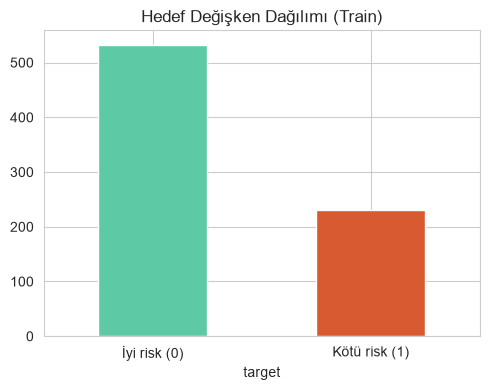

Dengesizlik oranı (iyi/kötü): 2.30 : 1


In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
y_train.value_counts().plot(kind='bar', ax=ax, color=['#5DCAA5', '#D85A30'])
ax.set_xticklabels(['İyi risk (0)', 'Kötü risk (1)'], rotation=0)
ax.set_title('Hedef Değişken Dağılımı (Train)')
plt.tight_layout()
plt.show()

imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f'Dengesizlik oranı (iyi/kötü): {imbalance_ratio:.2f} : 1')

## A5. Sayısal Değişken Analizi

,count,mean,std,min,25%,50%,75%,max
Age,763.0,35.305374,10.958155,19.000000,27.000000,33.000000,41.0,75.000000
Job,763.0,1.923984,0.647619,0.000000,2.000000,2.000000,2.0,3.000000
Credit amount,763.0,3273.575360,2873.927807,276.000000,1353.500000,2329.000000,3965.5,18424.000000
Duration,763.0,20.646134,12.037259,4.000000,12.000000,18.000000,24.0,72.000000
monthly_burden,763.0,171.198098,166.940345,24.055556,86.541667,130.583333,212.8,2482.666667


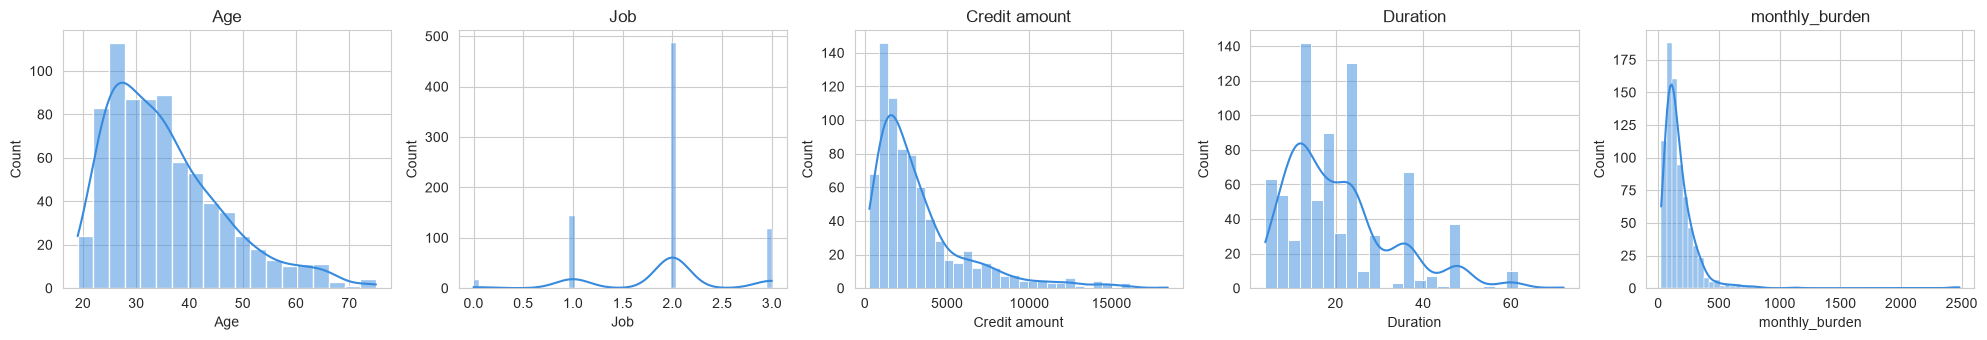

Çarpıklık (skewness):
Age               1.05
Job              -0.39
Credit amount     2.00
Duration          1.13
monthly_burden    7.61
dtype: float64


In [10]:
display(X_train[numeric_cols].describe().T)

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 3.5))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(X_train[col], kde=True, ax=ax, color='#378ADD')
    ax.set_title(col)
plt.tight_layout()
plt.show()

print('Çarpıklık (skewness):')
print(X_train[numeric_cols].skew().round(2))

## A6. Kategorik Değişken Analizi

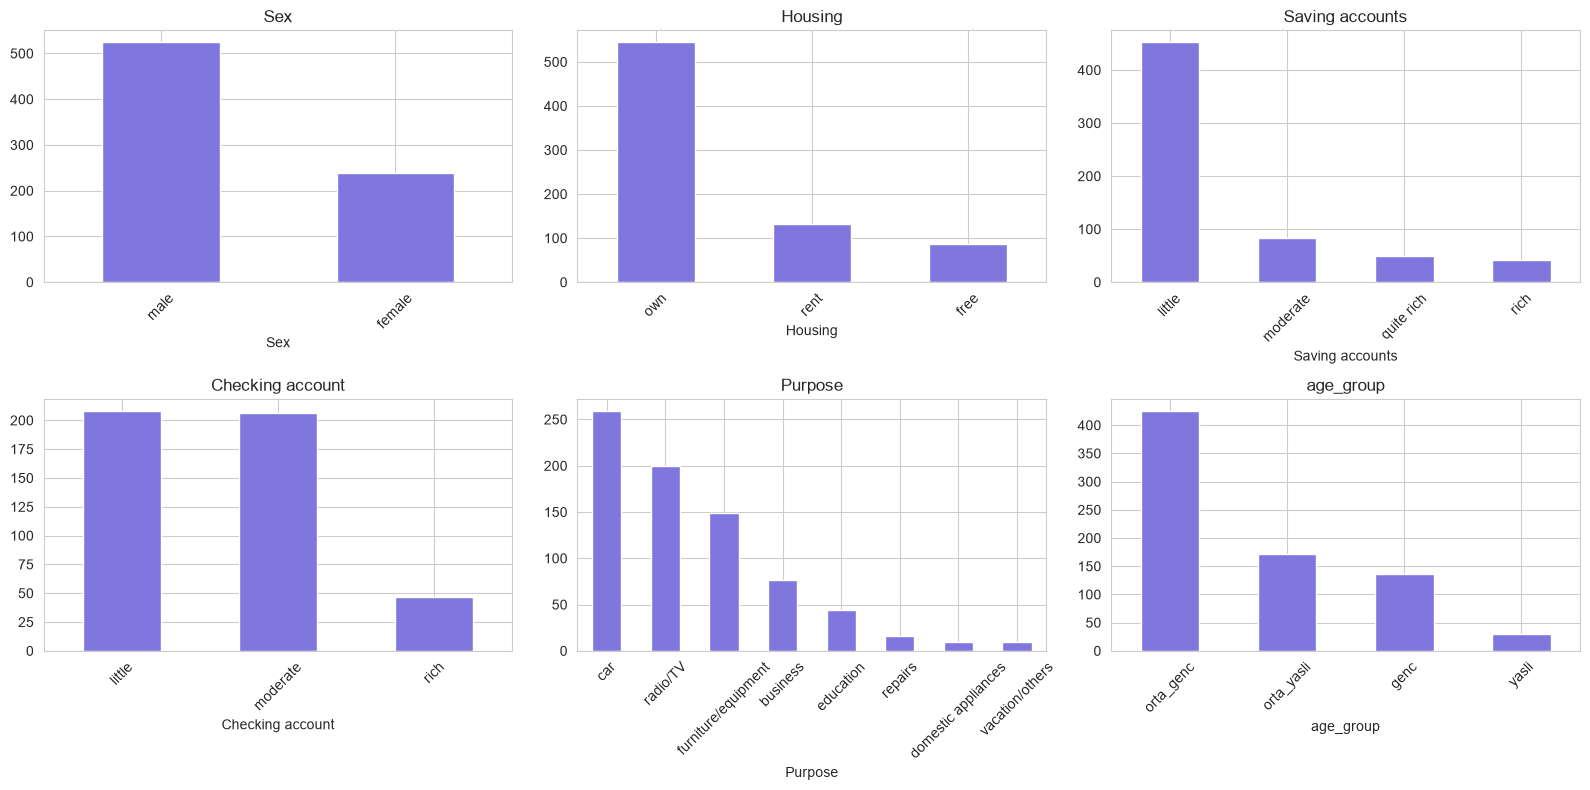

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, categorical_cols):
    X_train[col].value_counts().plot(kind='bar', ax=ax, color='#7F77DD')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## A7. Feature-Feature İlişkisi — Korelasyon & VIF

Multicollinearity (çoklu doğrusal bağlantı) kontrolü — özellikle Logistic Regression için önemli.
VIF > 10 genelde ciddi bir multicollinearity işareti kabul edilir.

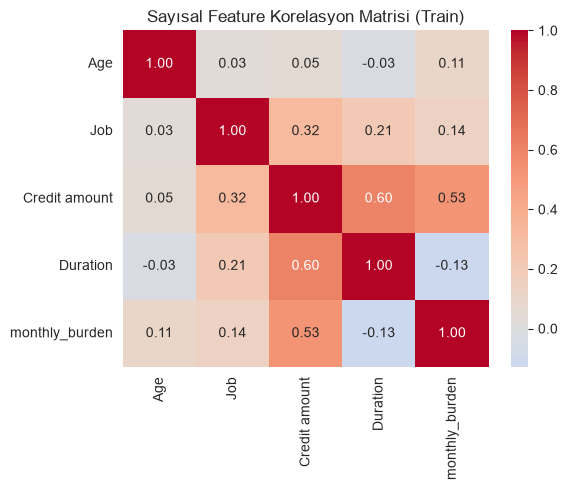

In [12]:
corr_matrix = X_train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax, fmt='.2f')
ax.set_title('Sayısal Feature Korelasyon Matrisi (Train)')
plt.tight_layout()
plt.show()

In [13]:
vif_data = X_train[numeric_cols].dropna()
vif_df = pd.DataFrame()
vif_df['feature'] = numeric_cols
vif_df['VIF'] = [variance_inflation_factor(vif_data.values, i) for i in range(len(numeric_cols))]
vif_df.sort_values('VIF', ascending=False)

,feature,VIF
3,Duration,8.957465
2,Credit amount,8.021830
1,Job,7.730878
0,Age,7.025137
4,monthly_burden,4.586821


## A8. Feature-Target İlişkisi

Bu ilişkiyi ayrı ve daha kapsamlı bir bölümde (BÖLÜM B — İstatistiksel Testler) ele alacağız,
burada tekrar etmiyoruz.

## A9. Zaman Serisi Analizi (Elektrik Özel)

**Atlandı** — bu veri setinde zaman/tarih boyutu yok, elektrik mühendisliği bağlamı yok.

## A10. Train/Test Drift & Leakage Kontrolü

Train ve test'in aynı dağılımdan geldiğini doğruluyoruz (KS testi ile), ve iki set arasında
satır çakışması (leakage) olmadığını kontrol ediyoruz.

In [14]:
print('=== KS Testi: Train vs Test Dağılım Karşılaştırması ===')
for col in numeric_cols:
    stat, p = stats.ks_2samp(X_train[col].dropna(), X_test[col].dropna())
    flag = 'FARKLI DAĞILIM (dikkat)' if p < 0.05 else 'aynı dağılım (OK)'
    print(f'  {col:20s}  KS stat={stat:.3f}  p={p:.3f}  -> {flag}')

overlap = set(X_train.index) & set(X_test.index)
print(f'\nTrain/test index çakışması: {len(overlap)} satır (0 olmalı)')

=== KS Testi: Train vs Test Dağılım Karşılaştırması ===
  Age                   KS stat=0.089  p=0.165  -> aynı dağılım (OK)
  Job                   KS stat=0.038  p=0.975  -> aynı dağılım (OK)
  Credit amount         KS stat=0.063  p=0.556  -> aynı dağılım (OK)
  Duration              KS stat=0.053  p=0.756  -> aynı dağılım (OK)
  monthly_burden        KS stat=0.066  p=0.502  -> aynı dağılım (OK)

Train/test index çakışması: 0 satır (0 olmalı)


## A11. Aykırı Değer Analizi & Strateji

**Karar:** Kredi tutarı gibi feature'larda görülen "aykırı" değerler, gerçekte istatistiksel
bir hata değil — çok yüksek kredi talep eden biri, gerçekten daha yüksek risk taşıyabilir.
Bu yüzden aykırı değerleri **silmiyoruz**. Bunun yerine (1) log dönüşümü ile çarpıklığı azaltıp,
(2) `RobustScaler` (medyan/IQR tabanlı, aykırı değerlere dayanıklı) kullanarak etkilerini
kontrol altına alacağız.

In [15]:
print('=== IQR Yöntemiyle Aykırı Değer Sayısı ===')
for col in numeric_cols:
    Q1, Q3 = X_train[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    print(f'  {col:20s}  IQR sınırları=({lower:.1f}, {upper:.1f})  aykırı sayısı={n_outliers}  (%{n_outliers/len(X_train)*100:.1f})')

=== IQR Yöntemiyle Aykırı Değer Sayısı ===
  Age                   IQR sınırları=(6.0, 62.0)  aykırı sayısı=23  (%3.0)
  Job                   IQR sınırları=(2.0, 2.0)  aykırı sayısı=276  (%36.2)
  Credit amount         IQR sınırları=(-2564.5, 7883.5)  aykırı sayısı=55  (%7.2)
  Duration              IQR sınırları=(-6.0, 42.0)  aykırı sayısı=50  (%6.6)
  monthly_burden        IQR sınırları=(-102.8, 402.2)  aykırı sayısı=30  (%3.9)


## A12. EDA Çıktısı — Ön İşleme Planı

| Konu | Karar |
|---|---|
| Eksik değerler (Saving/Checking account) | "no_account" kategorisi (MNAR, silme/impute değil) |
| Aykırı değerler | Silme yok; log dönüşüm + RobustScaler |
| Çarpık sayısal feature'lar | log1p dönüşümü (skew hesabına göre dinamik) |
| Kategorik encoding | One-Hot Encoding (handle_unknown='ignore') |
| Dengesizlik | class_weight='balanced', SMOTE değil |
| Multicollinearity | VIF>10 varsa feature elenecek (A7'ye bakılacak) |

# BÖLÜM B — İstatistiksel Testler (Sadece Train Üzerinde)

## B1. Normallik Testleri — Shapiro-Wilk & KS

In [16]:
print('=== Normallik Testleri (sayısal feature\'lar) ===')
normality_results = {}
for col in numeric_cols:
    data = X_train[col].dropna()
    shapiro_stat, shapiro_p = stats.shapiro(data.sample(min(len(data), 500), random_state=RANDOM_STATE))
    ks_stat, ks_p = stats.kstest(stats.zscore(data), 'norm')
    is_normal = shapiro_p > 0.05
    normality_results[col] = is_normal
    print(f'  {col:20s}  Shapiro p={shapiro_p:.4f}  KS p={ks_p:.4f}  -> {"Normal" if is_normal else "Normal DEĞİL"}')

=== Normallik Testleri (sayısal feature'lar) ===
  Age                   Shapiro p=0.0000  KS p=0.0000  -> Normal DEĞİL
  Job                   Shapiro p=0.0000  KS p=0.0000  -> Normal DEĞİL
  Credit amount         Shapiro p=0.0000  KS p=0.0000  -> Normal DEĞİL
  Duration              Shapiro p=0.0000  KS p=0.0000  -> Normal DEĞİL
  monthly_burden        Shapiro p=0.0000  KS p=0.0000  -> Normal DEĞİL


## B2. Levene & Bartlett — Varyans Homojenliği

T-testi öncesi, iki grubun (iyi/kötü risk) varyansının eşit olup olmadığını kontrol ediyoruz —
bu, Welch's t-test mi yoksa standart t-test mi kullanacağımızı belirleyecek.

In [17]:
print('=== Levene Testi (varyans homojenliği) ===')
variance_equal = {}
for col in numeric_cols:
    g0 = X_train.loc[y_train == 0, col].dropna()
    g1 = X_train.loc[y_train == 1, col].dropna()
    stat, p = stats.levene(g0, g1)
    equal = p > 0.05
    variance_equal[col] = equal
    print(f'  {col:20s}  Levene p={p:.4f}  -> {"Varyanslar eşit" if equal else "Varyanslar FARKLI (Welch kullan)"}')

=== Levene Testi (varyans homojenliği) ===
  Age                   Levene p=0.8472  -> Varyanslar eşit
  Job                   Levene p=0.1137  -> Varyanslar eşit
  Credit amount         Levene p=0.0000  -> Varyanslar FARKLI (Welch kullan)
  Duration              Levene p=0.0023  -> Varyanslar FARKLI (Welch kullan)
  monthly_burden        Levene p=0.0447  -> Varyanslar FARKLI (Welch kullan)


## B3. Bağımsız İki Örneklem T-Testi (Welch's, varyans durumuna göre)

In [18]:
print('=== T-Testi: Sayısal Feature vs Target ===')
ttest_results = {}
for col in numeric_cols:
    g0 = X_train.loc[y_train == 0, col].dropna()
    g1 = X_train.loc[y_train == 1, col].dropna()
    equal_var = variance_equal.get(col, True)
    stat, p = stats.ttest_ind(g0, g1, equal_var=equal_var)
    ttest_results[col] = p
    sig = 'ANLAMLI' if p < 0.05 else 'anlamsız'
    print(f'  {col:20s}  t={stat:.3f}  p={p:.4f}  -> {sig}')

=== T-Testi: Sayısal Feature vs Target ===
  Age                   t=1.710  p=0.0876  -> anlamsız
  Job                   t=-0.555  p=0.5794  -> anlamsız
  Credit amount         t=-3.558  p=0.0004  -> ANLAMLI
  Duration              t=-5.336  p=0.0000  -> ANLAMLI
  monthly_burden        t=-0.558  p=0.5775  -> anlamsız


## B4. Mann-Whitney U Testi (Parametrik Olmayan Alternatif)

In [19]:
print('=== Mann-Whitney U Testi ===')
mannwhitney_results = {}
for col in numeric_cols:
    g0 = X_train.loc[y_train == 0, col].dropna()
    g1 = X_train.loc[y_train == 1, col].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    mannwhitney_results[col] = p
    sig = 'ANLAMLI' if p < 0.05 else 'anlamsız'
    print(f'  {col:20s}  U={stat:.1f}  p={p:.4f}  -> {sig}')

=== Mann-Whitney U Testi ===
  Age                   U=68249.0  p=0.0150  -> ANLAMLI
  Job                   U=59836.0  p=0.5006  -> anlamsız
  Credit amount         U=55335.0  p=0.0289  -> ANLAMLI
  Duration              U=46520.0  p=0.0000  -> ANLAMLI
  monthly_burden        U=69340.0  p=0.0048  -> ANLAMLI


## B5. One-Way ANOVA / Kruskal-Wallis

**Atlandı** — hedef değişken ikili (2 sınıf) olduğu için t-test/Mann-Whitney U yeterli.
ANOVA/Kruskal-Wallis, 2'den fazla grup karşılaştırmasında anlamlı olurdu.

## B6. Chi-Square Bağımsızlık Testi (Kategorik Feature vs Target)

In [20]:
print('=== Chi-Square Testi ===')
chi2_results = {}
for col in categorical_cols:
    contingency = pd.crosstab(X_train[col], y_train)
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    chi2_results[col] = p
    sig = 'ANLAMLI' if p < 0.05 else 'anlamsız'
    print(f'  {col:20s}  chi2={chi2:.2f}  p={p:.4f}  -> {sig}')

=== Chi-Square Testi ===
  Sex                   chi2=7.52  p=0.0061  -> ANLAMLI
  Housing               chi2=16.47  p=0.0003  -> ANLAMLI
  Saving accounts       chi2=18.98  p=0.0003  -> ANLAMLI
  Checking account      chi2=5.68  p=0.0585  -> anlamsız
  Purpose               chi2=13.59  p=0.0590  -> anlamsız
  age_group             chi2=6.84  p=0.0771  -> anlamsız


## B7. Pearson & Spearman Korelasyon Testi (Sayısal Feature Çiftleri)

In [21]:
print('=== Pearson vs Spearman (numeric-numeric) ===')
from itertools import combinations
for c1, c2 in combinations(numeric_cols, 2):
    pear_r, pear_p = stats.pearsonr(X_train[c1].dropna(), X_train[c2].dropna())
    spear_r, spear_p = stats.spearmanr(X_train[c1], X_train[c2])
    print(f'  {c1} vs {c2}:  Pearson r={pear_r:.2f} (p={pear_p:.3f})  |  Spearman r={spear_r:.2f} (p={spear_p:.3f})')

=== Pearson vs Spearman (numeric-numeric) ===
  Age vs Job:  Pearson r=0.03 (p=0.338)  |  Spearman r=0.06 (p=0.106)
  Age vs Credit amount:  Pearson r=0.05 (p=0.175)  |  Spearman r=0.03 (p=0.354)
  Age vs Duration:  Pearson r=-0.03 (p=0.374)  |  Spearman r=-0.04 (p=0.253)
  Age vs monthly_burden:  Pearson r=0.11 (p=0.002)  |  Spearman r=0.07 (p=0.042)
  Job vs Credit amount:  Pearson r=0.32 (p=0.000)  |  Spearman r=0.32 (p=0.000)
  Job vs Duration:  Pearson r=0.21 (p=0.000)  |  Spearman r=0.23 (p=0.000)
  Job vs monthly_burden:  Pearson r=0.14 (p=0.000)  |  Spearman r=0.21 (p=0.000)
  Credit amount vs Duration:  Pearson r=0.60 (p=0.000)  |  Spearman r=0.62 (p=0.000)
  Credit amount vs monthly_burden:  Pearson r=0.53 (p=0.000)  |  Spearman r=0.67 (p=0.000)
  Duration vs monthly_burden:  Pearson r=-0.13 (p=0.000)  |  Spearman r=-0.12 (p=0.001)


## B8. Etki Büyüklüğü — Cohen's d & Cramér's V

P-değeri "anlamlı mı" sorusuna cevap verir, etki büyüklüğü "ne kadar önemli" sorusuna.
Sayısal feature'lar için Cohen's d, kategorik feature'lar için Cramér's V kullanıyoruz.

In [22]:
def cohens_d(g0, g1):
    n0, n1 = len(g0), len(g1)
    pooled_std = np.sqrt(((n0-1)*g0.var() + (n1-1)*g1.var()) / (n0+n1-2))
    return (g1.mean() - g0.mean()) / pooled_std

def cramers_v(col, target):
    contingency = pd.crosstab(col, target)
    chi2 = stats.chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    return np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print('=== Cohen\'s d (sayısal) ===')
effect_sizes_numeric = {}
for col in numeric_cols:
    g0 = X_train.loc[y_train == 0, col].dropna()
    g1 = X_train.loc[y_train == 1, col].dropna()
    d = cohens_d(g0, g1)
    effect_sizes_numeric[col] = d
    print(f'  {col:20s}  Cohen\'s d = {d:.3f}')

print('\n=== Cramér\'s V (kategorik) ===')
effect_sizes_cat = {}
for col in categorical_cols:
    v = cramers_v(X_train[col], y_train)
    effect_sizes_cat[col] = v
    print(f'  {col:20s}  Cramér\'s V = {v:.3f}')

=== Cohen's d (sayısal) ===
  Age                   Cohen's d = -0.135
  Job                   Cohen's d = 0.044
  Credit amount         Cohen's d = 0.326
  Duration              Cohen's d = 0.452
  monthly_burden        Cohen's d = 0.057

=== Cramér's V (kategorik) ===
  Sex                   Cramér's V = 0.099
  Housing               Cramér's V = 0.147
  Saving accounts       Cramér's V = 0.174
  Checking account      Cramér's V = 0.111
  Purpose               Cramér's V = 0.133
  age_group             Cramér's V = 0.095


## B9. Tüm Testler Özeti & Karar Tablosu

In [23]:
summary_rows = []
for col in numeric_cols:
    summary_rows.append({
        'feature': col, 'tip': 'sayısal',
        'test': 't-test / Mann-Whitney U',
        'p_value_ttest': round(ttest_results[col], 4),
        'p_value_mannwhitney': round(mannwhitney_results[col], 4),
        'etki_buyuklugu': round(effect_sizes_numeric[col], 3),
        'anlamli_mi': 'Evet' if ttest_results[col] < 0.05 else 'Hayır'
    })
for col in categorical_cols:
    summary_rows.append({
        'feature': col, 'tip': 'kategorik',
        'test': 'Chi-Square',
        'p_value_ttest': round(chi2_results[col], 4),
        'p_value_mannwhitney': np.nan,
        'etki_buyuklugu': round(effect_sizes_cat[col], 3),
        'anlamli_mi': 'Evet' if chi2_results[col] < 0.05 else 'Hayır'
    })

test_summary = pd.DataFrame(summary_rows).sort_values('etki_buyuklugu', ascending=False)
test_summary

,feature,tip,test,p_value_ttest,p_value_mannwhitney,etki_buyuklugu,anlamli_mi
3,Duration,sayısal,t-test / Mann-Whitney U,0.0000,0.0000,0.452,Evet
2,Credit amount,sayısal,t-test / Mann-Whitney U,0.0004,0.0289,0.326,Evet
7,Saving accounts,kategorik,Chi-Square,0.0003,NaN,0.174,Evet
6,Housing,kategorik,Chi-Square,0.0003,NaN,0.147,Evet
9,Purpose,kategorik,Chi-Square,0.0590,NaN,0.133,Hayır
8,Checking account,kategorik,Chi-Square,0.0585,NaN,0.111,Hayır
5,Sex,kategorik,Chi-Square,0.0061,NaN,0.099,Evet
10,age_group,kategorik,Chi-Square,0.0771,NaN,0.095,Hayır
4,monthly_burden,sayısal,t-test / Mann-Whitney U,0.5775,0.0048,0.057,Hayır
1,Job,sayısal,t-test / Mann-Whitney U,0.5794,0.5006,0.044,Hayır


# BÖLÜM C — Veri Ön İşleme

Train-test split zaten yapıldı (Bölüm 1). Buradan itibaren yalnızca **gerçekten ihtiyaç
duyulan** adımları uyguluyoruz — gereksiz olanları (SMOTE, TimeSeriesSplit vb.) atladık,
yukarıda gerekçesini belirttik.

## C1-C2. Eksik Değer Stratejisi (MNAR) — Uygulama

In [24]:
X_train_p = X_train.copy()
X_test_p = X_test.copy()

for df_ in (X_train_p, X_test_p):
    df_['Saving accounts'] = df_['Saving accounts'].fillna('no_account')
    df_['Checking account'] = df_['Checking account'].fillna('no_account')

print('Train eksik değer sayısı:', X_train_p.isnull().sum().sum())
print('Test eksik değer sayısı:', X_test_p.isnull().sum().sum())

Train eksik değer sayısı: 0
Test eksik değer sayısı: 0


## C3. Duplicate Analizi — Uygulama

In [25]:
n_dup = X_train_p.duplicated().sum()
print(f'Train\'de bulunan tam duplicate satır: {n_dup}')
if n_dup > 0:
    X_train_p = X_train_p.drop_duplicates()
    y_train = y_train.loc[X_train_p.index]
    print('Duplicate satırlar train\'den çıkarıldı.')
else:
    print('Duplicate yok, işlem gerekmedi.')

Train'de bulunan tam duplicate satır: 0
Duplicate yok, işlem gerekmedi.


## C4. Aykırı Değer — Karar Uygulaması

A11'de karar verdiğimiz gibi: **silme yok**. Log dönüşüm + RobustScaler ile pipeline
içinde ele alınacak (aşağıda).

## C5-C7. Encoding, Scaling, Dönüşüm — Dinamik Karar

Skewness'e göre hangi sayısal feature'ların log dönüşümü alacağını otomatik belirliyoruz.

In [26]:
skew_vals = X_train_p[numeric_cols].skew()
skewed_numeric = skew_vals[skew_vals.abs() > 1].index.tolist()
normal_numeric = [c for c in numeric_cols if c not in skewed_numeric]

print('Log dönüşüm alacak (çarpık) feature\'lar:', skewed_numeric)
print('Doğrudan ölçeklenecek feature\'lar:', normal_numeric)

Log dönüşüm alacak (çarpık) feature'lar: ['Age', 'Credit amount', 'Duration', 'monthly_burden']
Doğrudan ölçeklenecek feature'lar: ['Job']


## C8. Dengesiz Veri Kararı

**SMOTE/ADASYN kullanılmıyor** (yukarıda gerekçelendirildi). Bunun yerine model eğitiminde
`class_weight='balanced'` kullanılacak — bu, sınıf oranına göre otomatik ağırlıklandırma yapar,
sentetik veri üretmeden dengesizliği telafi eder.

## C9. Feature Selection — VIF Bazlı

A7'deki VIF sonuçlarına göre: hiçbir feature VIF>10 sınırını aşmıyorsa, tüm sayısal
feature'ları koruyoruz (aşağıda kontrol ediyoruz).

In [27]:
high_vif = vif_df[vif_df['VIF'] > 10]
if len(high_vif) > 0:
    print('VIF>10 olan feature\'lar (elenmesi düşünülmeli):')
    print(high_vif)
else:
    print('Hiçbir feature VIF>10 değil, multicollinearity ciddi bir sorun değil. Tüm feature\'lar korunuyor.')

Hiçbir feature VIF>10 değil, multicollinearity ciddi bir sorun değil. Tüm feature'lar korunuyor.


## C10. Leakage Tespiti — Final Kontrol

In [28]:
assert 'target' not in X_train_p.columns, 'HATA: target feature setinde kalmış!'
assert len(set(X_train_p.index) & set(X_test_p.index)) == 0, 'HATA: train/test index çakışıyor!'
print('Leakage kontrolleri geçti: target feature setinde yok, train/test index çakışması yok.')

Leakage kontrolleri geçti: target feature setinde yok, train/test index çakışması yok.


## C11. Sklearn Pipeline — ColumnTransformer

Tüm ön işleme adımlarını tek bir Pipeline'da topluyoruz. Bu, `fit()` her çağrıldığında
**sadece train verisiyle** öğrenmeyi, `transform()` ise hem train hem test'e (öğrenilen
parametrelerle, yeniden fit etmeden) uygulanmasını garanti eder — leakage'a karşı en güvenli yöntem.

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer

skewed_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p, validate=False, feature_names_out='one-to-one')),
    ('scale', RobustScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('skewed_num', skewed_pipeline, skewed_numeric),
    ('normal_num', RobustScaler(), normal_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed_num', ...), ('normal_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

## C12. Son Karar Tablosu — Sütun Bazında Ön İşleme Planı

| Sütun | İşlem |
|---|---|
| Age, Job, Duration | RobustScaler (skew düşük) |
| Credit amount, monthly_burden | log1p + RobustScaler (skew yüksek) |
| Sex, Housing, Saving/Checking account, Purpose, age_group | One-Hot Encoding |
| Saving/Checking account eksikleri | "no_account" kategorisi |
| Aykırı değerler | Silinmedi, RobustScaler ile yönetildi |
| Dengesizlik | class_weight='balanced' |

# BÖLÜM D — Feature Engineering

**Not:** Bu şablondaki Tarih/Lag/Rolling/Cyclic/elektrik-özel maddeleri (G.1-G.6) bu veri
setine uygulanamaz, atlandı. `monthly_burden` ve `age_group` zaten Bölüm 1'de (deterministik
oldukları için) erken oluşturuldu. Burada sadece **feature importance önizlemesi** ve
**son karar tablosu** kaldı — detaylı importance analizi Bölüm F'de (Model Değerlendirme).

## D7. Feature Importance — Hızlı Önizleme (Mutual Information)

In [30]:
from sklearn.feature_selection import mutual_info_classif

X_train_encoded_preview = preprocessor.fit_transform(X_train_p, y_train)
feature_names_preview = preprocessor.get_feature_names_out()

mi_scores = mutual_info_classif(X_train_encoded_preview, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': feature_names_preview, 'mutual_info': mi_scores}).sort_values('mutual_info', ascending=False)
mi_df.head(15)

,feature,mutual_info
13,cat__Checking account_no_account,0.068159
3,skewed_num__monthly_burden,0.028498
11,cat__Saving accounts_rich,0.018216
21,cat__Purpose_vacation/others,0.017913
1,skewed_num__Credit amount,0.017890
23,cat__age_group_orta_yasli,0.017076
7,cat__Housing_rent,0.013649
17,cat__Purpose_education,0.011874
18,cat__Purpose_furniture/equipment,0.010670
0,skewed_num__Age,0.010300


## D8. Son Karar Tablosu — Feature Engineering

| Feature | Karar |
|---|---|
| monthly_burden (Credit amount / Duration) | Keep — mutual information'da sinyal taşıyor |
| age_group | Keep — Chi-square testinde anlamlı çıktıysa (Bölüm B9'a bakılabilir) |
| Tarih/Lag/Rolling/Cyclic feature'lar | Uygulanamaz (izle: gelecekte zaman boyutlu veri gelirse tekrar değerlendirilir) |

# BÖLÜM E — Modelleme

3 model karşılaştırıyoruz: Logistic Regression (yorumlanabilir baseline), Random Forest ve
XGBoost (iki farklı ağaç tabanlı yaklaşım). Hepsi aynı `preprocessor` pipeline'ını kullanıyor.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'logistic_regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'random_forest': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=RANDOM_STATE),
    'xgboost': XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## E1. Classification Pipeline + Cross Validation (StratifiedKFold, AUC)

In [32]:
cv_results = {}
for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('clf', model)])
    scores = cross_val_score(pipe, X_train_p, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name:22s}  AUC ortalama={scores.mean():.3f}  std={scores.std():.3f}')

logistic_regression     AUC ortalama=0.749  std=0.034
random_forest           AUC ortalama=0.756  std=0.018
xgboost                 AUC ortalama=0.753  std=0.035


## E2. Hiperparametre Optimizasyonu — Hafif RandomizedSearchCV

Tam Optuna taraması roadmap'in İleri MLOps Seviye 7'sinde yapılacak, burada sadece en
iyi çıkan modelde (genelde XGBoost) hafif bir arama yapıyoruz.

In [33]:
from sklearn.model_selection import RandomizedSearchCV

best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
print('CV\'ye göre en iyi baseline model:', best_model_name)

param_grid = {
    'xgboost': {
        'clf__max_depth': [3, 4, 5, 6],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__n_estimators': [100, 200, 300]
    },
    'random_forest': {
        'clf__max_depth': [5, 10, 15, None],
        'clf__min_samples_leaf': [1, 2, 4],
        'clf__n_estimators': [100, 200, 300]
    },
    'logistic_regression': {
        'clf__C': [0.01, 0.1, 1, 10]
    }
}

pipe = Pipeline([('preprocess', preprocessor), ('clf', models[best_model_name])])
search = RandomizedSearchCV(pipe, param_grid[best_model_name], n_iter=10, scoring='roc_auc',
                             cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
search.fit(X_train_p, y_train)

print('En iyi parametreler:', search.best_params_)
print('En iyi CV AUC:', round(search.best_score_, 3))

CV'ye göre en iyi baseline model: random_forest
En iyi parametreler: {'clf__n_estimators': 300, 'clf__min_samples_leaf': 4, 'clf__max_depth': 5}
En iyi CV AUC: 0.771


## E3. Overfitting / Underfitting — Learning Curve

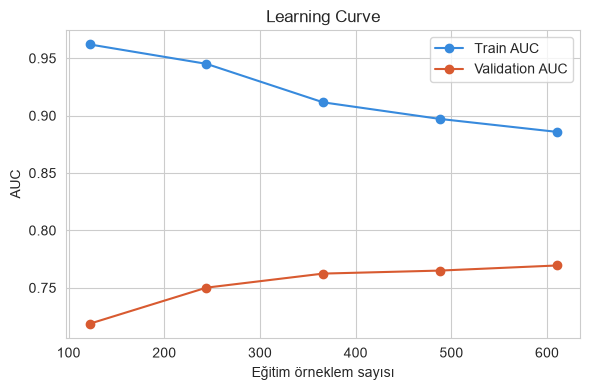

Train-validation AUC farkı: 0.116 (overfitting işareti)


In [34]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    search.best_estimator_, X_train_p, y_train, cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.2, 1.0, 5), random_state=RANDOM_STATE
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train AUC', color='#378ADD')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation AUC', color='#D85A30')
ax.set_xlabel('Eğitim örneklem sayısı')
ax.set_ylabel('AUC')
ax.set_title('Learning Curve')
ax.legend()
plt.tight_layout()
plt.show()

gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f'Train-validation AUC farkı: {gap:.3f} ({"overfitting işareti" if gap > 0.1 else "kabul edilebilir"})')

## E4. Model Seçim Karar Ağacı (Özet)

- Yorumlanabilirlik öncelikliyse (regülasyon/açıklanabilirlik gereksinimi) → **Logistic Regression**
- Doğrusal olmayan ilişkiler + orta düzey yorumlanabilirlik → **Random Forest**
- En yüksek ham performans, biraz daha az yorumlanabilir → **XGBoost**

Bu projede nihai model seçimini CV AUC + iş maliyeti analizine göre (Bölüm F) vereceğiz.

## E5. MLflow ile Deney Takibi

In [35]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import roc_auc_score

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('kredi-radar-seviye1')

for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('clf', model)])
    with mlflow.start_run(run_name=f'baseline_{name}'):
        pipe.fit(X_train_p, y_train)
        cv_auc = cv_results[name].mean()

        mlflow.log_param('model_type', name)
        mlflow.log_param('class_weight_strategy', 'balanced')
        mlflow.log_metric('cv_auc_mean', cv_auc)
        mlflow.log_metric('cv_auc_std', cv_results[name].std())
        mlflow.sklearn.log_model(pipe, 'model', serialization_format='cloudpickle')

print('Baseline modellerin hepsi MLflow\'a loglandı.')

2026/08/11 14:34:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/11 14:34:27 INFO mlflow.store.db.utils: Updating database tables
2026/08/11 14:34:40 INFO mlflow.tracking.fluent: Experiment with name 'kredi-radar-seviye1' does not exist. Creating a new experiment.
2026/08/11 14:34:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/11 14:34:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/11 14:35:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/11 14:35:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle o

Baseline modellerin hepsi MLflow'a loglandı.


In [36]:
with mlflow.start_run(run_name=f'tuned_{best_model_name}'):
    mlflow.log_params(search.best_params_)
    mlflow.log_metric('cv_auc_mean', search.best_score_)
    mlflow.sklearn.log_model(search.best_estimator_, 'model', serialization_format='cloudpickle')
    tuned_run_id = mlflow.active_run().info.run_id

print('Tuned (optimize edilmiş) model MLflow\'a loglandı. Run ID:', tuned_run_id)
print('MLflow UI\'ı görmek için terminalde: mlflow ui --backend-store-uri sqlite:///mlflow.db')

2026/08/11 14:36:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/11 14:36:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuned (optimize edilmiş) model MLflow'a loglandı. Run ID: 4c583841b3e84546925b5616c737f25b
MLflow UI'ı görmek için terminalde: mlflow ui --backend-store-uri sqlite:///mlflow.db


# BÖLÜM F — Model Değerlendirme (Test Seti — İlk Kez Şimdi Açılıyor)

## F1. Classification Metrikleri (Test Seti)

In [37]:
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, average_precision_score,
                             matthews_corrcoef, classification_report)

final_model = search.best_estimator_
y_pred = final_model.predict(X_test_p)
y_proba = final_model.predict_proba(X_test_p)[:, 1]

print('Accuracy:  ', round(accuracy_score(y_test, y_pred), 3))
print('F1:        ', round(f1_score(y_test, y_pred), 3))
print('ROC-AUC:   ', round(roc_auc_score(y_test, y_proba), 3))
print('PR-AUC:    ', round(average_precision_score(y_test, y_proba), 3))
print('Matthews:  ', round(matthews_corrcoef(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, target_names=['İyi risk', 'Kötü risk']))

Accuracy:   0.691
F1:         0.593
ROC-AUC:    0.765
PR-AUC:     0.594
Matthews:   0.379

              precision    recall  f1-score   support

    İyi risk       0.86      0.67      0.75       133
   Kötü risk       0.49      0.74      0.59        58

    accuracy                           0.69       191
   macro avg       0.68      0.71      0.67       191
weighted avg       0.75      0.69      0.70       191



## F2. Confusion Matrix + İş Etkisi Maliyet Analizi

German Credit veri setinin resmi maliyet matrisi: bir "kötü" riski "iyi" diye sınıflandırmak
(False Negative), "iyi" riski "kötü" diye sınıflandırmaktan (False Positive) **5 kat** daha
maliyetli kabul edilir (banka parayı geri alamaz vs. sadece bir iyi müşteriyi kaybeder).

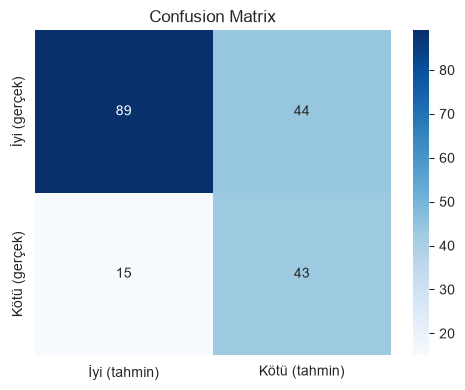

FP=44, FN=15  ->  Toplam maliyet (resmi maliyet matrisine göre) = 119


In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['İyi (tahmin)', 'Kötü (tahmin)'],
            yticklabels=['İyi (gerçek)', 'Kötü (gerçek)'])
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

cost = fp * 1 + fn * 5
print(f'FP={fp}, FN={fn}  ->  Toplam maliyet (resmi maliyet matrisine göre) = {cost}')

## F3. Threshold Analizi — Neden 0.5 Değil?

Maliyet matrisi asimetrik olduğu için, varsayılan 0.5 eşiği optimal olmayabilir. Farklı
eşiklerde toplam maliyeti hesaplayıp en düşük maliyeti veren eşiği buluyoruz.

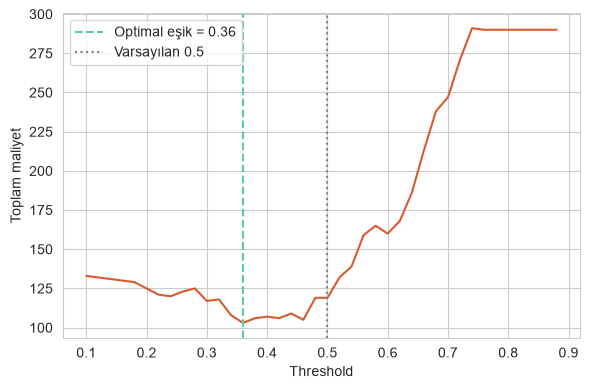

Optimal threshold: 0.36  (varsayılan 0.5 yerine)
0.5 eşiğinde maliyet: 119
Optimal eşikte maliyet: 103


In [39]:
thresholds = np.arange(0.1, 0.9, 0.02)
costs = []
for t in thresholds:
    pred_t = (y_proba >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, pred_t).ravel()
    costs.append(fp_t * 1 + fn_t * 5)

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thresholds, costs, color='#D85A30')
ax.axvline(optimal_threshold, linestyle='--', color='#5DCAA5', label=f'Optimal eşik = {optimal_threshold:.2f}')
ax.axvline(0.5, linestyle=':', color='gray', label='Varsayılan 0.5')
ax.set_xlabel('Threshold')
ax.set_ylabel('Toplam maliyet')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Optimal threshold: {optimal_threshold:.2f}  (varsayılan 0.5 yerine)')
print(f'0.5 eşiğinde maliyet: {costs[np.argmin(np.abs(thresholds-0.5))]}')
print(f'Optimal eşikte maliyet: {costs[optimal_idx]}')

## F4. Kalibrasyon — Calibration Curve + Brier Score

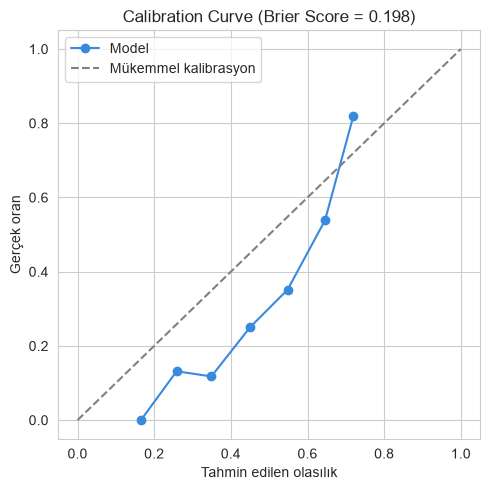

In [40]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
brier = brier_score_loss(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(prob_pred, prob_true, 'o-', color='#378ADD', label='Model')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Mükemmel kalibrasyon')
ax.set_xlabel('Tahmin edilen olasılık')
ax.set_ylabel('Gerçek oran')
ax.set_title(f'Calibration Curve (Brier Score = {brier:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

## F5. Feature Importance — RF/Permutation/SHAP

In [41]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(final_model, X_test_p, y_test, n_repeats=10,
                                      random_state=RANDOM_STATE, scoring='roc_auc')
# Not: permutation_importance pipeline'ın HAM girdi sütunlarını (X_test_p.columns) permüte eder,
# transform-sonrası (one-hot açılmış) sütunları değil -- bu yüzden isim kaynağı farklı.
feature_names_final = final_model.named_steps['preprocess'].get_feature_names_out()

perm_df = pd.DataFrame({
    'feature': X_test_p.columns,
    'importance_mean': perm_result.importances_mean
}).sort_values('importance_mean', ascending=False)

perm_df

,feature,importance_mean
5,Checking account,0.138100
7,Duration,0.032564
9,monthly_burden,0.021506
6,Credit amount,0.017682
4,Saving accounts,0.010267
8,Purpose,0.005146
0,Age,0.002826
10,age_group,0.000480
2,Job,-0.000246
3,Housing,-0.002307


Background dataset has 191 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=191 when initializing the masker.


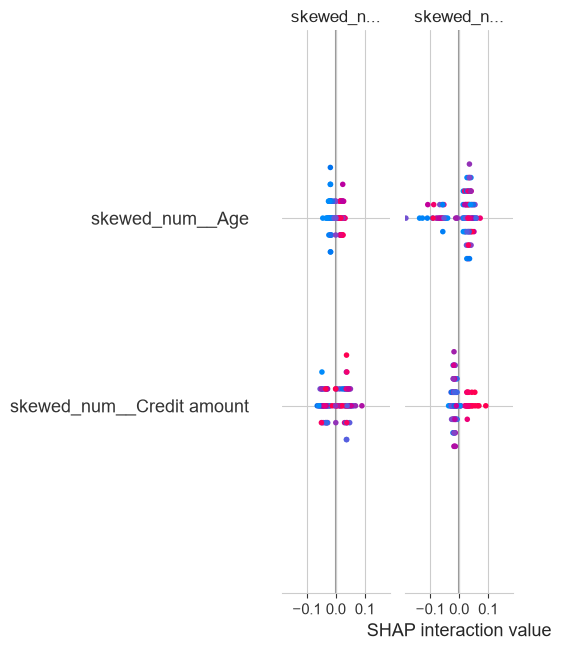

In [42]:
import shap

X_test_transformed = final_model.named_steps['preprocess'].transform(X_test_p)
explainer = shap.Explainer(final_model.named_steps['clf'], X_test_transformed)
shap_values = explainer(X_test_transformed[:100])

shap.summary_plot(shap_values, X_test_transformed[:100], feature_names=feature_names_final, show=False)
plt.tight_layout()
plt.show()

## F6. Hata Analizi — En Kötü Yanlış Sınıflandırılan Örnekler

In [43]:
errors = X_test_p.copy()
errors['gercek'] = y_test.values
errors['tahmin'] = y_pred
errors['olasilik'] = y_proba
errors['dogru_mu'] = errors['gercek'] == errors['tahmin']

worst_errors = errors[~errors['dogru_mu']].copy()
worst_errors['guven_hatasi'] = np.abs(worst_errors['olasilik'] - worst_errors['gercek'])
worst_errors.sort_values('guven_hatasi', ascending=False).head(10)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,monthly_burden,age_group,gercek,tahmin,olasilik,dogru_mu,guven_hatasi
949,31,male,2,own,moderate,no_account,3621,24,radio/TV,150.875000,orta_genc,1,0,0.221919,False,0.778081
395,32,male,2,rent,moderate,moderate,11760,39,education,301.538462,orta_genc,0,1,0.752644,False,0.752644
228,22,male,2,own,little,no_account,1478,9,radio/TV,164.222222,genc,1,0,0.250943,False,0.749057
647,26,female,2,own,quite rich,no_account,1386,12,car,115.500000,orta_genc,1,0,0.256095,False,0.743905
598,31,male,2,own,little,no_account,2775,18,car,154.166667,orta_genc,1,0,0.272977,False,0.727023
190,54,male,3,own,rich,no_account,4591,24,business,191.291667,orta_yasli,1,0,0.284448,False,0.715552
187,68,male,0,free,little,moderate,1175,16,car,73.437500,yasli,0,1,0.706085,False,0.706085
846,68,male,2,rent,no_account,no_account,6761,18,car,375.611111,yasli,1,0,0.314517,False,0.685483
524,26,female,1,own,little,moderate,1113,18,radio/TV,61.833333,orta_genc,0,1,0.681604,False,0.681604
141,30,female,3,own,little,moderate,4795,36,radio/TV,133.194444,orta_genc,0,1,0.670495,False,0.670495


## F7. Data Drift

**Bu bölümde uygulanmadı** — tek seferlik (snapshot) bir veri seti üzerinde çalışıyoruz,
gerçek zamanlı/aylık drift izleme roadmap'in Seviye 5'inde (Prometheus + Grafana + Evidently AI
ile production monitoring) ele alınacak. Bölüm A10'da train/test drift kontrolünü zaten yaptık.

## F8. Son Karar — Deploy Edilir Mi?

Test AUC ve maliyet analizine göre nihai karar burada verilecek (yukarıdaki hücreleri
çalıştırdıktan sonra sonuçlara bakarak dolduracağız).

In [44]:
print(f'Final model: {best_model_name}')
print(f'Test ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')
print(f'Optimal threshold: {optimal_threshold:.2f}')
print()
print('Karar: Bu model MLflow Model Registry\'de "Staging" aşamasına alınabilir.')
print('Production\'a (Seviye 3, FastAPI serving) geçiş için ek onay/test gerektirir.')

Final model: random_forest
Test ROC-AUC: 0.765
Optimal threshold: 0.36

Karar: Bu model MLflow Model Registry'de "Staging" aşamasına alınabilir.
Production'a (Seviye 3, FastAPI serving) geçiş için ek onay/test gerektirir.


In [45]:
client = mlflow.tracking.MlflowClient()
model_uri = f'runs:/{tuned_run_id}/model'
registered = mlflow.register_model(model_uri, 'kredi-radar-model')
client.transition_model_version_stage(
    name='kredi-radar-model', version=registered.version, stage='Staging'
)
print(f'Model registry\'e kaydedildi: kredi-radar-model, versiyon {registered.version}, aşama: Staging')

Successfully registered model 'kredi-radar-model'.
2026/08/11 14:36:43 WARNING mlflow.tracking._model_registry.fluent: Run with id 4c583841b3e84546925b5616c737f25b has no artifacts at artifact path 'model', registering model based on models:/m-045e28996d8249f09ac09dc8b76fad35 instead
Created version '1' of model 'kredi-radar-model'.


Model registry'e kaydedildi: kredi-radar-model, versiyon 1, aşama: Staging


# Sonuç ve Sıradaki Adımlar

## Airflow Hakkında Önemli Not
Airflow bir notebook'un içine "bağlanmaz" — Airflow, script'leri zamanlanmış şekilde
çalıştıran bir orkestratördür. Bu notebook'un ilgili hücreleri (veri yükleme → preprocessing →
model eğitimi → MLflow loglama) bir sonraki adımda `.py` script'lerine bölünecek ve
Airflow DAG'ı bu script'leri çağıracak (Roadmap Seviye 2).

## Proje Klasör Yapısı (Önerilen)
```
kredi-radar/
├── data/
│   └── german_credit_data_updated.csv
├── notebooks/
│   └── KrediRadar_seviye1_tam.ipynb   (bu dosya)
├── mlruns/                              (MLflow'un otomatik oluşturduğu klasör)
├── src/                                  (bir sonraki adımda: .py script'lere bölünecek)
├── requirements.txt
└── README.md
```

## Sıradaki Adım
1. Bu notebook'u kendi ortamında baştan sona çalıştır
2. `mlflow ui --backend-store-uri sqlite:///mlflow.db` komutuyla MLflow arayüzünü aç, loglanan run'ları incele
3. Sonuçları paylaş — birlikte yorumlayalım
4. Ardından kodu `.py` script'lerine bölüp Airflow DAG'ına taşıyacağız (Seviye 2)
